# 04 - End-to-end pipeline evaluation

Chains the 3 trained models (`SkuExtractionPipeline` in `src/inference.py`):

```
raw photo -> localize -> pad+crop -> orient -> derotate -> read -> SKU string
```

Each of notebooks 01-03 trained and measured its stage in isolation against
ground truth (or, for stage 3, against stage 2's ground-truth crop rather
than its actual prediction). None of that measures what happens when a
stage's own prediction error feeds into the next stage - that's what this
notebook is actually for.

Evaluated by **fetching fresh photos live** from `label-generator-api` for
the real 20-item product catalog - SKUs none of the 3 models have ever seen
in training, in images none of them have ever seen at all (not even the
held-out ones from `data/raw/`).

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise RuntimeError("Could not locate the vision-ml project root from " + str(start))


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/lroland/Projects/github.com/distribution-center/vision-ml')

In [2]:
import csv
import random

import matplotlib.pyplot as plt

from src import client, inference, settings

random.seed(0)
DEVICE = "cpu"  # a handful of live single-image inferences - not worth MPS transfer overhead


## Load the 3 trained checkpoints

In [3]:
pipeline = inference.SkuExtractionPipeline(
    localizer_path=settings.MODELS_DIR / "localizer.pt",
    orientation_path=settings.MODELS_DIR / "orientation.pt",
    ocr_path=settings.MODELS_DIR / "ocr.pt",
    device=DEVICE,
)


## Fetch fresh photos of the real catalog and predict

In [4]:
with open(PROJECT_ROOT.parent / "products.csv") as f:
    catalog_skus = [row["sku"] for row in csv.DictReader(f)]

IMAGES_PER_SKU = 3
results = []
for sku in catalog_skus:
    for _ in range(IMAGES_PER_SKU):
        image = client.fetch_sticker(sku, color_mode="random", image_format="jpg")
        prediction = pipeline.predict(image)
        results.append({"true_sku": sku, "pred_sku": prediction.sku, "image": image, "prediction": prediction})

exact_matches = sum(r["true_sku"] == r["pred_sku"] for r in results)
print(f"end-to-end exact-match accuracy: {exact_matches}/{len(results)} = {exact_matches / len(results):.1%}")


end-to-end exact-match accuracy: 35/60 = 58.3%


## Per-SKU breakdown

In [5]:
from collections import defaultdict

per_sku = defaultdict(list)
for r in results:
    per_sku[r["true_sku"]].append(r["true_sku"] == r["pred_sku"])

print(f"{'SKU':<12} accuracy")
for sku in catalog_skus:
    hits = per_sku[sku]
    print(f"{sku:<12} {sum(hits)}/{len(hits)}")


SKU          accuracy
SKU-1001     3/3
SKU-1002     1/3
SKU-1003     2/3
SKU-1004     2/3
SKU-1005     2/3
SKU-1006     1/3
SKU-1007     0/3
SKU-1008     3/3
SKU-1009     2/3
SKU-1010     3/3
SKU-1011     3/3
SKU-1012     1/3
SKU-1013     3/3
SKU-1014     1/3
SKU-1015     1/3
SKU-1016     0/3
SKU-1017     1/3
SKU-1018     2/3
SKU-1019     2/3
SKU-1020     2/3


## Failure cases

Each panel shows the raw photo the pipeline actually saw and the crop it fed to the OCR stage - a garbled or blank crop points at a localization/orientation error; a clean, upright, correct-looking crop with a wrong reading points at an OCR error.

25 failures out of 60


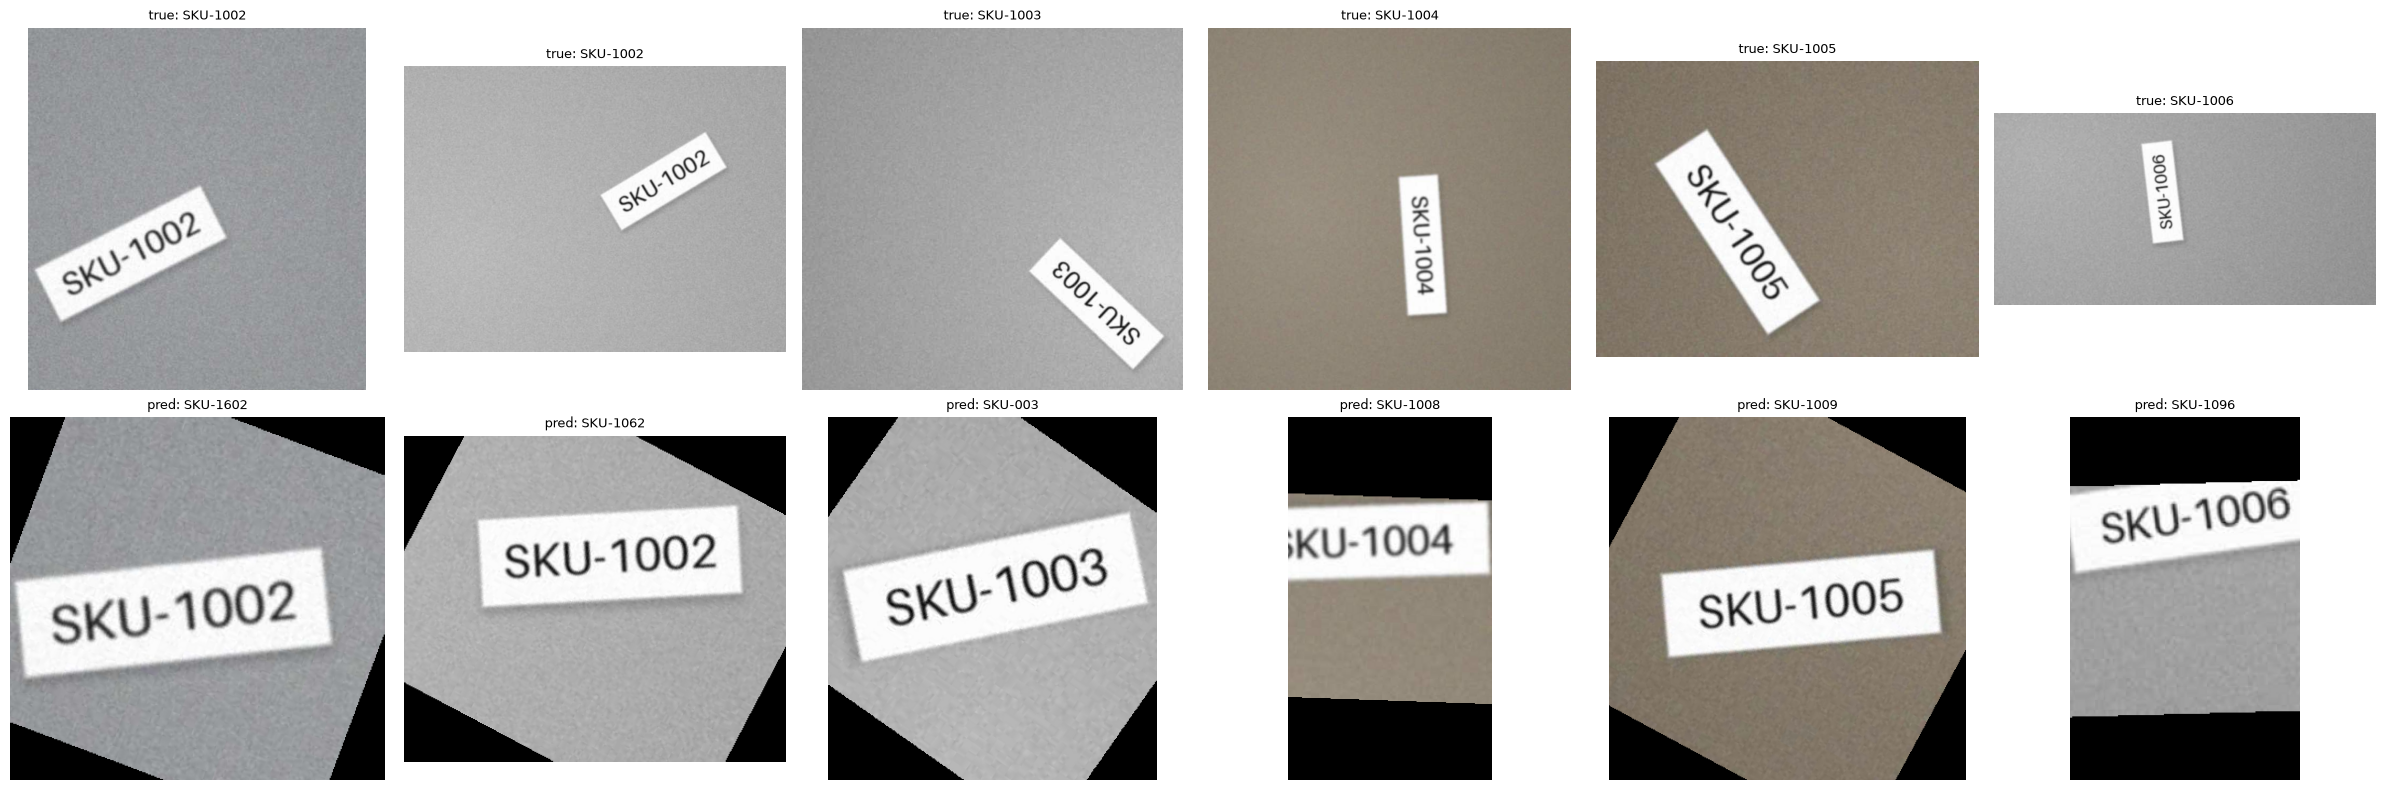

In [6]:
failures = [r for r in results if r["true_sku"] != r["pred_sku"]]
print(f"{len(failures)} failures out of {len(results)}")

if failures:
    n = min(len(failures), 6)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    for col, r in enumerate(failures[:n]):
        axes[0, col].imshow(r["image"])
        axes[0, col].set_title(f"true: {r['true_sku']}", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(r["prediction"].crop)
        axes[1, col].set_title(f"pred: {r['pred_sku']}", fontsize=9)
        axes[1, col].axis("off")
    axes[0, 0].set_ylabel("raw photo", fontsize=10)
    axes[1, 0].set_ylabel("OCR input crop", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No failures in this sample - try increasing IMAGES_PER_SKU above for a tighter accuracy estimate.")


## Findings: chained accuracy vs. isolated accuracy

End-to-end exact-match accuracy (58%) is meaningfully lower than each stage's
own isolated numbers would suggest (~0.70 mean IoU localization, ~4 degree
mean angular error orientation, ~91% catalog exact-match OCR against
ground-truth crops) - three individually decent stages don't multiply out to
a proportionally good chained pipeline. Two things drove most of the gap
while building this:

- **Train/inference distribution mismatch.** The first version of stages 2
  and 3 trained only against pixel-perfect ground-truth crops and scored
  33% end-to-end despite each stage looking good in isolation - they'd never
  seen the kind of off-center, oddly-scaled crop stage 1's real (imperfect)
  predictions actually produce, so they were fragile to it. Adding
  position/scale jitter to `OrientationDataset`/`OcrDataset` (see
  `geometry.jitter_bbox`) to simulate that raised this notebook's accuracy to
  58%. The remaining gap is visible above: some failures are still a
  slightly-clipped crop from stage 1's imprecision, others are a clean,
  correctly-oriented crop the OCR stage simply misread a digit on.
- **Not every stage tolerates every kind of noise equally.** Rotation jitter
  broke the OCR stage's training outright (loss never moved), while the same
  magnitude of position/scale jitter was fine for both stages - reading text
  is far more sensitive to orientation than a global-average-pooled
  regression head is to translation. The practical split that emerged:
  stage 2 is responsible for actually straightening the crop; stage 3 only
  needs to tolerate imprecise *cropping*, not imprecise *rotation*.

A production version of this pipeline would likely go further - e.g. a
larger/longer-trained localizer for tighter boxes, jitter magnitude tuned
against the localizer's actual error distribution rather than hand-picked,
or a single end-to-end-fine-tuned pass chaining real (not ground-truth)
stage 1/2 outputs into stage 3's loss.